Shape: (50000, 13)
Rows: 50000
Columns: 13

Column Names:
Index(['User_ID', 'Age', 'Gender', 'Occupation', 'Device_Type',
       'Daily_Phone_Hours', 'Social_Media_Hours', 'Work_Productivity_Score',
       'Sleep_Hours', 'Stress_Level', 'App_Usage_Count',
       'Caffeine_Intake_Cups', 'Weekend_Screen_Time_Hours'],
      dtype='object')

Cleaned Column Names:
Index(['User_ID', 'Age', 'Gender', 'Occupation', 'Device_Type',
       'Daily_Phone_Hours', 'Social_Media_Hours', 'Work_Productivity_Score',
       'Sleep_Hours', 'Stress_Level', 'App_Usage_Count',
       'Caffeine_Intake_Cups', 'Weekend_Screen_Time_Hours'],
      dtype='object')

Data Types:
User_ID                       object
Age                            int64
Gender                        object
Occupation                    object
Device_Type                   object
Daily_Phone_Hours            float64
Social_Media_Hours           float64
Work_Productivity_Score        int64
Sleep_Hours                  float64
Stress_Leve

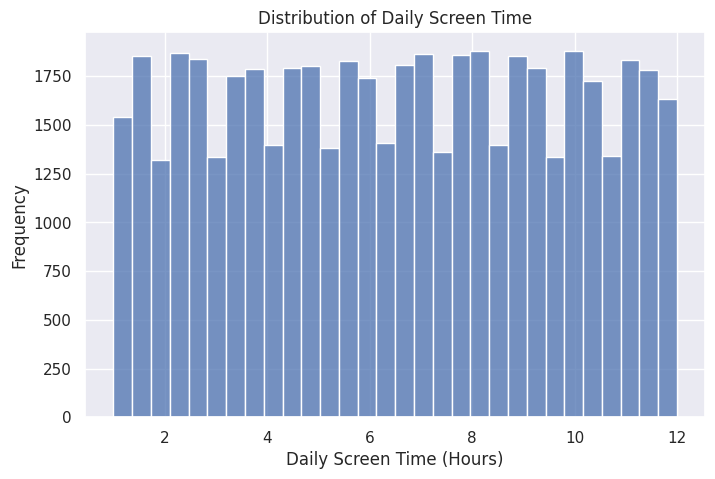

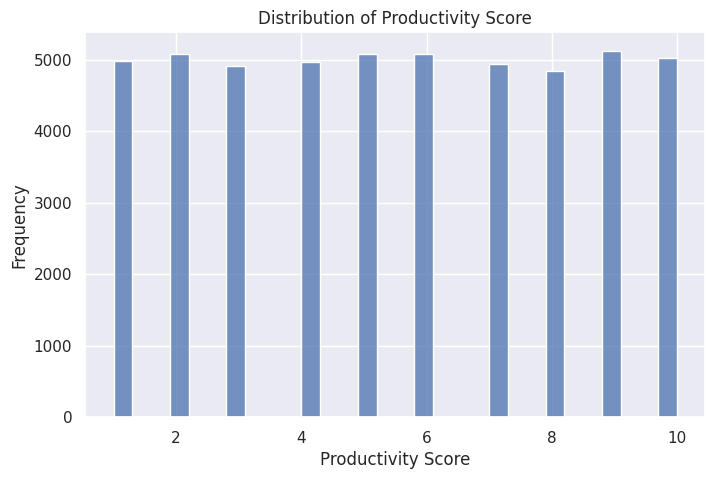

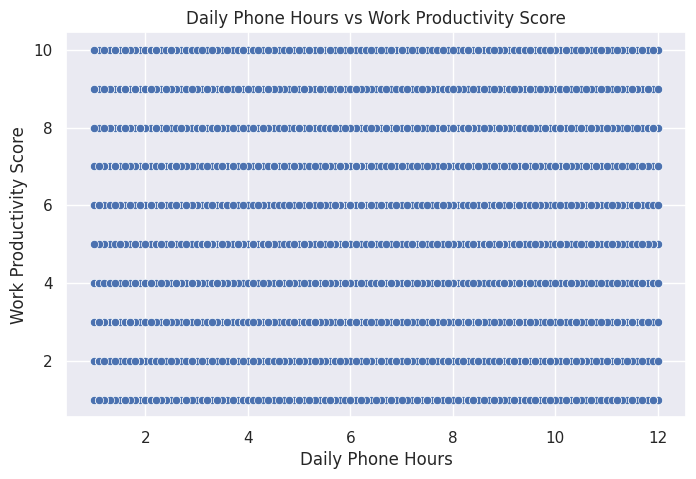

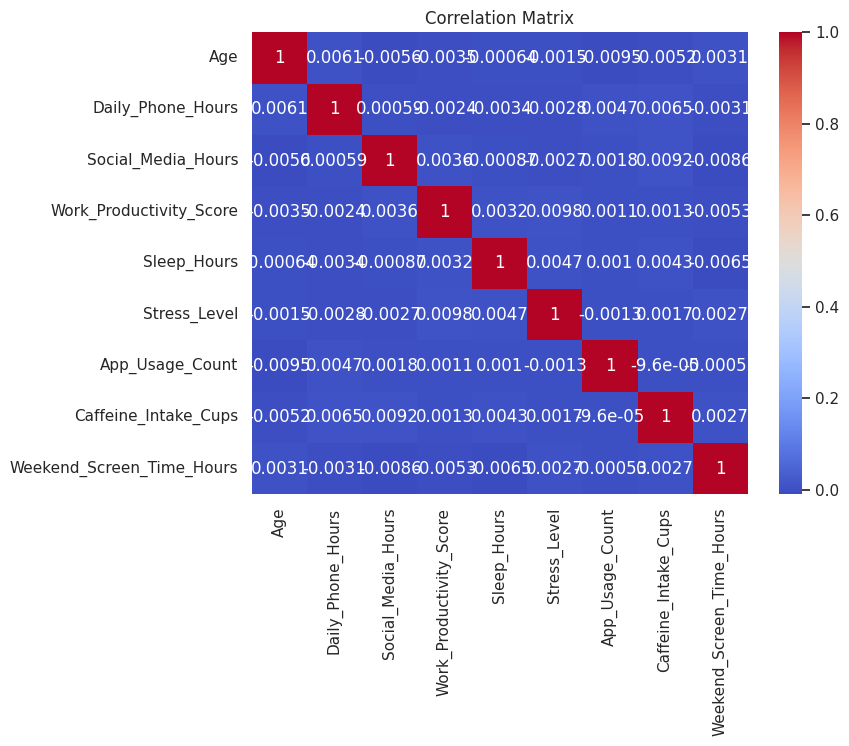


Usage Category Distribution:
Usage_Category
High      27183
Medium    13503
Low        9314
Name: count, dtype: int64


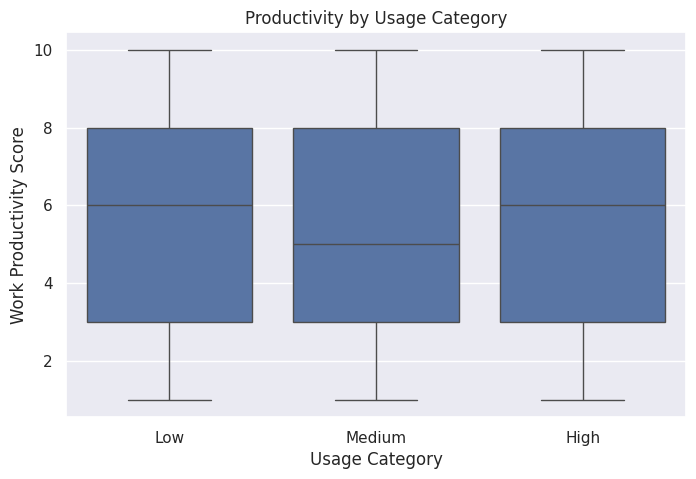


Average Productivity by Usage Category:
Usage_Category
Low       5.527271
Medium    5.492927
High      5.501085
Name: Work_Productivity_Score, dtype: float64


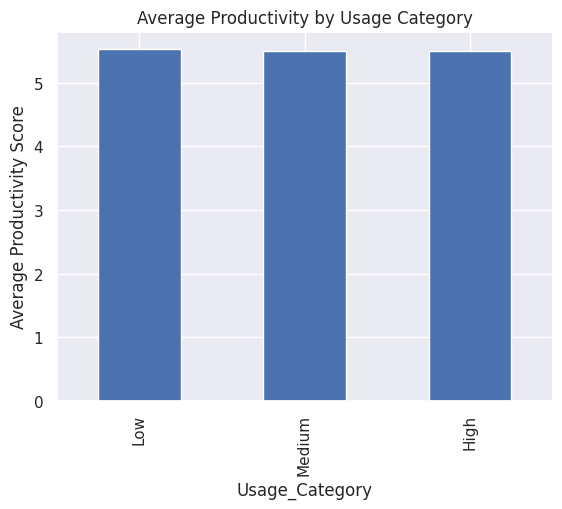

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()
df = pd.read_csv("/kaggle/input/datasets/ghadeeralmudhi/smartphone-usage-productivity/Smartphone_Usage_Productivity_Dataset_50000.csv")
df.head()

print("Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns)

df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace("(", "").str.replace(")", "")
print("\nCleaned Column Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isna().sum())

print("\nDuplicate Rows:", df.duplicated().sum())
df = df.drop_duplicates()

print("\nDescriptive Statistics:")
print(df.describe())

plt.figure(figsize=(8,5))
sns.histplot(df['Daily_Phone_Hours'], bins=30)
plt.title("Distribution of Daily Screen Time")
plt.xlabel("Daily Screen Time (Hours)")
plt.ylabel("Frequency")
plt.show()


plt.figure(figsize=(8,5))
sns.histplot(df['Work_Productivity_Score'], bins=30)
plt.title("Distribution of Productivity Score")
plt.xlabel("Productivity Score")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x='Daily_Phone_Hours',
                y='Work_Productivity_Score',
                data=df)
plt.title("Daily Phone Hours vs Work Productivity Score")
plt.xlabel("Daily Phone Hours")
plt.ylabel("Work Productivity Score")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

df['Usage_Category'] = pd.cut(
    df['Daily_Phone_Hours'],
    bins=[0,3,6,12],
    labels=['Low','Medium','High']
)

print("\nUsage Category Distribution:")
print(df['Usage_Category'].value_counts())

plt.figure(figsize=(8,5))
sns.boxplot(x='Usage_Category',
            y='Work_Productivity_Score',
            data=df)
plt.title("Productivity by Usage Category")
plt.xlabel("Usage Category")
plt.ylabel("Work Productivity Score")
plt.show()

usage_productivity = df.groupby('Usage_Category', observed=False)['Work_Productivity_Score'].mean()

print("\nAverage Productivity by Usage Category:")
print(usage_productivity)

usage_productivity.plot(kind='bar')
plt.title("Average Productivity by Usage Category")
plt.ylabel("Average Productivity Score")
plt.show()